# Holiday Identification by Daily Profile Clustering

This notebook flags atypical days in one demand series by comparing each daily profile against its `(segment, weekday)` reference group.

It loads observed data, builds day-level profiles, measures distance to the group centroid, and compares detected outliers against the local holiday catalog.

This is exploratory notebook code, not part of the production pipeline.

In [21]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analog_holidays.shared.dataset_config import ACTIVE_CONFIG, list_dataset_regions
from analog_holidays.shared.identify_holidays import (
    build_holiday_groups,
    build_holiday_selector_features,
    build_wide_df,
    compare_outliers_holidays,
    compute_distances,
    detect_outliers,
    display_cluster_holiday_crosstab,
    display_cluster_38h_crosstab,
    find_holidays_not_detected,
    get_date_sets,
    get_hour_cols,
    load_holidays_catalog,
    load_results_data,
    plot_distance_distribution,
    plot_profiles_by_holiday,
    plot_profiles_by_segment_dow,
    print_summary,
    report_nth_monday_holidays,
    run_cluster_ab_validation,
    run_cluster_38h_analysis,
    run_cluster_atypical_analysis,
    run_holiday_ab_validation,
)

DEMAND_PATH = ACTIVE_CONFIG.demand_path
HOLIDAYS_PATH = ACTIVE_CONFIG.notebook_holidays_path

print(f'Active dataset: {ACTIVE_CONFIG.key}')
print(f'Demand CSV: {DEMAND_PATH}')
print(f'Holidays: {HOLIDAYS_PATH}')


Active dataset: mx
Demand CSV: C:\GIT\analog_holidays\holidays\holiday_demand_mx.csv
Holidays: C:\GIT\analog_holidays\holidays\holidays_recognized.json


## 1. Configuration

In [22]:
UNIQUE_ID = 'SEN_demand_SIN'

DATE_END = '2025-01-01'
SELECTOR_FUTURE_END = '2026-12-31'

AVAILABLE_UNIQUE_IDS = list_dataset_regions()
if not AVAILABLE_UNIQUE_IDS:
    raise ValueError(f'No configured series were found in {DEMAND_PATH}.')
if UNIQUE_ID is None:
    UNIQUE_ID = AVAILABLE_UNIQUE_IDS[0]
elif UNIQUE_ID not in AVAILABLE_UNIQUE_IDS:
    raise ValueError(
        f'Series {UNIQUE_ID!r} not found. Available: {AVAILABLE_UNIQUE_IDS}'
    )

MONTH_NAMES = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December',
]

SEGMENTS = [
    {'label': 'Spring', 'months': [3, 4, 5]},
    {'label': 'Summer', 'months': [6, 7, 8]},
    {'label': 'Autumn', 'months': [9, 10, 11]},
    {'label': 'Winter', 'months': [12, 1, 2]},
]

SEGMENTS = [{'label': month_name, 'months': [month_number]} for month_number, month_name in enumerate(MONTH_NAMES, start=1)]

OUTLIER_PERCENTILE = 95
EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE = True
KNOWN_HOLIDAY_MIN_GROUP_PERCENTILE = 75
DISTANCE_METRIC = 'PEARSON'

N_CLUSTERS_PHOL    = 3   # clusters for 38-h eve+holiday profiles (section 8c-bis)
PREVIOUSLY_W_HOURS = 14  # hours taken from the eve day

WEEKDAY_NAMES = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print(f'Series:   {UNIQUE_ID}')
print(f'DATE_END: {DATE_END}')
print(f'SELECTOR_FUTURE_END: {SELECTOR_FUTURE_END}')
print(f'Available series: {AVAILABLE_UNIQUE_IDS}')


Series:   SEN_demand_SIN
DATE_END: 2025-01-01
SELECTOR_FUTURE_END: 2026-12-31
Available series: ['SEN_demand_SIN', 'SEN_demand_CEL', 'SEN_demand_OCC', 'SEN_demand_NOR', 'SEN_demand_PEN', 'SEN_demand_ORI', 'SEN_demand_NES', 'SEN_demand_NTE']


## 2. Load observed data from CSV

In [23]:
MONTH_TO_SEGMENT = {month: segment['label'] for segment in SEGMENTS for month in segment['months']}
SEGMENT_LABELS = [segment['label'] for segment in SEGMENTS]

df_raw = load_results_data(DEMAND_PATH, UNIQUE_ID)
if DATE_END is not None:
    cutoff_ts = pd.Timestamp(DATE_END)
    df_raw = df_raw[df_raw['ds'] < cutoff_ts].copy()
    if df_raw.empty:
        raise ValueError(f'No data available for {UNIQUE_ID} before {cutoff_ts.date()}.')

print(f'Series: {UNIQUE_ID}')
print(f'Records: {len(df_raw):,}')
if DATE_END is not None:
    print(f'DATE_END cutoff: {pd.Timestamp(DATE_END).date()} (exclusive)')
print(f'Range: {df_raw["ds"].min()} → {df_raw["ds"].max()}')
df_raw.head()

Series: SEN_demand_SIN
Records: 35,016
DATE_END cutoff: 2025-01-01 (exclusive)
Range: 2020-01-02 00:00:00 → 2024-12-31 23:00:00


,ds,y
0,2020-01-02 00:00:00,24878.55898
1,2020-01-02 01:00:00,23313.94064
2,2020-01-02 02:00:00,22549.69591
3,2020-01-02 03:00:00,22035.66456
4,2020-01-02 04:00:00,21564.47956


## 3. Pivot to wide format (1 row = 1 day, 24 columns = hours)

In [24]:
df_wide = build_wide_df(df_raw, MONTH_TO_SEGMENT, exclude_years=[2022])
HOUR_COLS = get_hour_cols(df_wide)
year_min = int(df_wide.index.year.min())
year_max = int(df_wide.index.year.max())
df_holidays = load_holidays_catalog(HOLIDAYS_PATH, year_min, year_max)
df_holidays_display = df_holidays.copy()
KNOWN_HOLIDAY_DATES = (
    set(pd.to_datetime(df_holidays['date']).dt.normalize())
    if EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE else set()
 )

print(f'Complete days: {len(df_wide)}')
print(f'Segments ({len(SEGMENT_LABELS)}):')
for segment_label in SEGMENT_LABELS:
    n_days = (df_wide['segment'] == segment_label).sum()
    print(f'  {segment_label}: {n_days} days')
print(f'Catalog holidays in range: {len(df_holidays)}')
print(f'Dates excluded from the baseline: {len(KNOWN_HOLIDAY_DATES)}')
df_wide.head()

Complete days: 1459
Segments (12):
  January: 123 days
  February: 114 days
  March: 124 days
  April: 118 days
  May: 124 days
  June: 120 days
  July: 124 days
  August: 124 days
  September: 120 days
  October: 124 days
  November: 120 days
  December: 124 days
Catalog holidays in range: 60
Dates excluded from the baseline: 60


hour,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,dow,month,segment
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,24878.55898,23313.94064,22549.69591,22035.66456,21564.47956,21741.03764,22472.88995,23986.04907,25455.25686,27020.45055,...,30848.95733,30866.21784,32436.44957,33411.38367,33132.91360,32189.18103,31143.56622,3,1,January
2020-01-03,30001.99703,28152.86370,27082.52642,26256.14433,26011.87978,25805.85191,26181.63198,27098.37405,28065.65345,29171.37021,...,31955.22462,31867.44179,33084.71334,34192.45690,33775.37621,32794.50828,31810.06945,4,1,January
2020-01-04,30489.08216,28608.67621,27737.78695,26776.73430,26358.79658,26098.39458,26419.03001,27038.61512,27658.72976,28370.59840,...,29131.68867,29512.16619,31494.03895,31943.83569,31429.73634,30806.57518,30169.95431,5,1,January
2020-01-05,28531.87871,27033.45162,25755.62921,24969.30620,24507.32207,24260.62141,24198.82634,24370.70753,24161.68269,24673.66761,...,26529.96262,26944.97391,29134.37077,31128.95514,30866.93363,30330.61622,28886.99283,6,1,January
2020-01-06,27432.84122,25903.69829,24917.56148,24345.79621,24002.04411,24162.61018,24900.94333,26480.53246,28072.87424,29750.41797,...,32516.01269,32380.74657,33598.81198,34505.85856,34101.55003,32937.77371,31823.38221,0,1,January


## 4. Compute distances by segment and weekday

Distances are computed inside each `(segment, dow)` group against that group's reference centroid.

`DISTANCE_METRIC` controls whether the score emphasizes magnitude, shape, or both.

In [25]:
df_dist = compute_distances(
    df_wide,
    HOUR_COLS,
    SEGMENT_LABELS,
    WEEKDAY_NAMES,
    distance_metric=DISTANCE_METRIC,
    reference_exclude_dates=KNOWN_HOLIDAY_DATES,
 )

print(f'Distance metric: {DISTANCE_METRIC}')
if DISTANCE_METRIC == 'PEARSON_EUCLIDIAN':
    print('  Euclidean and Pearson components combined after group-wise normalization')
elif DISTANCE_METRIC == 'EUCLIDIAN':
    print('  Euclidean distance only')
elif DISTANCE_METRIC == 'PEARSON':
    print('  1 - Pearson r only')
print(f'\nSegments: {SEGMENT_LABELS}')
print(f'Total records (day × group): {len(df_dist)}')
df_dist.head(10)

Distance metric: PEARSON
  1 - Pearson r only

Segments: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
Total records (day × group): 1459


,date,segment,dow,dow_name,dist_eucl,dist_pearson,dist_eucl_norm,dist_pearson_norm,is_reference_day,distance
0,2020-01-06,January,0,Monday,10186.145449,0.001592,1.611017,-0.708350,True,-0.708350
1,2020-01-13,January,0,Monday,3089.935137,0.002025,-0.905771,-0.535926,True,-0.535926
2,2020-01-20,January,0,Monday,3830.352932,0.008658,-0.643170,2.102584,True,2.102584
3,2020-01-27,January,0,Monday,3830.122284,0.002921,-0.643252,-0.179799,True,-0.179799
4,2021-01-04,January,0,Monday,8512.883473,0.005433,1.017567,0.819592,True,0.819592
5,2021-01-11,January,0,Monday,1707.177994,0.003511,-1.396189,0.055016,True,0.055016
6,2021-01-18,January,0,Monday,5634.921773,0.001438,-0.003150,-0.769633,True,-0.769633
7,2021-01-25,January,0,Monday,2024.528537,0.003863,-1.283635,0.195276,True,0.195276
8,2023-01-02,January,0,Monday,10604.926422,0.009807,1.759545,2.559867,True,2.559867
9,2023-01-09,January,0,Monday,4112.067787,0.000638,-0.543255,-1.087869,True,-1.087869


## 6. Load the local recognized holidays catalog (`holidays/holidays_recognized.json`)

In [26]:
df_dist, df_outliers = detect_outliers(
    df_dist,
    OUTLIER_PERCENTILE,
    threshold_reference_only=EXCLUDE_KNOWN_HOLIDAYS_FROM_BASELINE,
    promote_dates=KNOWN_HOLIDAY_DATES,
    promote_min_group_percentile=KNOWN_HOLIDAY_MIN_GROUP_PERCENTILE,
)

print(f'Detected outliers: {len(df_outliers)}')
print(f'Out of a total of {len(df_dist)} days')
print(f'Percentage: {100 * len(df_outliers) / len(df_dist):.1f}%')
print(f'Known holidays rescued by within-group percentile: {int(df_dist["is_promoted_outlier"].sum())}')
df_outliers.head(20)

Detected outliers: 131
Out of a total of 1459 days
Percentage: 9.0%
Known holidays rescued by within-group percentile: 47


,date,segment,dow,dow_name,dist_eucl,dist_pearson,dist_eucl_norm,dist_pearson_norm,is_reference_day,distance,threshold,group_percentile,is_outlier,is_promoted_outlier
13,2024-01-01,January,0,Monday,45425.506759,0.574977,14.109240,227.393757,False,227.393757,2.194040,100.000000,True,True
75,2021-01-01,January,4,Friday,47250.635301,0.594950,15.029250,99.562189,False,99.562189,1.985597,100.000000,True,True
253,2024-03-18,March,0,Monday,13554.260798,0.147575,2.141357,79.790202,False,79.790202,1.579019,100.000000,True,True
1387,2024-12-25,December,2,Wednesday,42834.104788,0.466541,8.598618,64.433223,False,64.433223,1.590117,100.000000,True,True
1409,2020-12-25,December,4,Friday,47327.451406,0.461999,10.978713,62.272069,False,62.272069,2.418858,100.000000,True,True
1227,2023-11-20,November,0,Monday,18337.330466,0.151711,2.173341,60.495676,False,60.495676,1.782918,100.000000,True,True
1231,2024-11-18,November,0,Monday,12446.565703,0.146830,0.986452,58.498509,False,58.498509,1.782918,94.444444,True,True
985,2024-09-16,September,0,Monday,20658.720389,0.205142,1.738498,55.339272,False,55.339272,1.881253,100.000000,True,True
244,2021-03-15,March,0,Monday,19434.250810,0.103189,4.038434,55.188836,False,55.188836,1.579019,94.444444,True,True
249,2023-03-20,March,0,Monday,22872.846118,0.097366,5.147837,51.961589,False,51.961589,1.579019,88.888889,True,True


## 6. Load the local recognized holidays catalog (`holidays/holidays_recognized.json`)

In [27]:
print(f'Generated holidays: {len(df_holidays_display)} (from {year_min} to {year_max})')
df_holidays_display.tail(15)


Generated holidays: 60 (from 2020 to 2024)


,date,holiday_name
45,2023-12-24,Christmas Eve
46,2023-12-25,Christmas Day
47,2023-12-31,New Year's Eve
48,2024-01-01,New Year's Day
49,2024-02-05,Constitution Day
50,2024-03-18,Benito Juarez's Birthday
51,2024-03-28,Maundy Thursday
52,2024-03-29,Good Friday
53,2024-03-30,Holy Saturday
54,2024-05-01,Labor Day


## 6b. Holidays with an nth-Monday rule

Three civic holidays moved from fixed dates to observed Mondays after the 2006 Federal Labor Law reform. Years before 2006 keep the historical fixed date.

| Holiday | Before 2006 | Since 2006 |
|---|---|---|
| Constitution Day | February 5 | 1st Monday of February |
| Benito Juarez's Birthday | March 21 | 3rd Monday of March |
| Mexican Revolution Day | November 20 | 3rd Monday of November |

In [28]:
df_nth = report_nth_monday_holidays(df_holidays)

print(f'Holidays with an nth-Monday rule (since 2006): {len(df_nth)} occurrences')
display(
    df_nth.rename(columns={
        'holiday_name': 'Holiday',
        'date': 'Observed date',
        'weekday_name': 'Weekday',
        'labor_law_rule': 'LFT rule',
    })
)

Holidays with an nth-Monday rule (since 2006): 15 occurrences


,Holiday,Observed date,Weekday,LFT rule
0,Constitution Day,2020-02-03,Monday,1st Monday of February (since 2006)
1,Benito Juarez's Birthday,2020-03-16,Monday,3rd Monday of March (since 2006)
2,Mexican Revolution Day,2020-11-16,Monday,3rd Monday of November (since 2006)
3,Constitution Day,2021-02-01,Monday,1st Monday of February (since 2006)
4,Benito Juarez's Birthday,2021-03-15,Monday,3rd Monday of March (since 2006)
5,Mexican Revolution Day,2021-11-15,Monday,3rd Monday of November (since 2006)
6,Constitution Day,2022-02-07,Monday,1st Monday of February (since 2006)
7,Benito Juarez's Birthday,2022-03-21,Monday,3rd Monday of March (since 2006)
8,Mexican Revolution Day,2022-11-21,Monday,3rd Monday of November (since 2006)
9,Constitution Day,2023-02-06,Monday,1st Monday of February (since 2006)


## 7. Compare outliers vs known holidays

In [29]:
df_match, stats = compare_outliers_holidays(df_outliers, df_holidays)
df_outliers_cmp = df_match
df_match_display = df_match.copy()

n_total = stats['n_total']
n_match = stats['n_match']
n_unknown = stats['n_unknown']

print('Outlier comparison against the holiday catalog')
print(f'Total outliers: {n_total}')
print(f'Match a known holiday: {n_match} ({100 * n_match / n_total:.0f}%)')
print(f'No catalog match: {n_unknown} ({100 * n_unknown / n_total:.0f}%)')

cols_display = ['date', 'dow_name', 'segment', 'distance', 'holiday_name']

print('\nKnown holidays detected as outliers')
display(
    df_match_display[df_match_display['is_known_holiday']]
    .sort_values('holiday_name')[cols_display]
 )

print('\nOutliers without a catalog match')
display(
    df_match_display[~df_match_display['is_known_holiday']]
    .sort_values('holiday_name')[cols_display]
 )

Outlier comparison against the holiday catalog
Total outliers: 131
Match a known holiday: 47 (36%)
No catalog match: 84 (64%)

Known holidays detected as outliers


,date,dow_name,segment,distance,holiday_name
11,2020-03-16,Monday,March,41.857850,Benito Juarez's Birthday
2,2024-03-18,Monday,March,79.790202,Benito Juarez's Birthday
9,2023-03-20,Monday,March,51.961589,Benito Juarez's Birthday
8,2021-03-15,Monday,March,55.188836,Benito Juarez's Birthday
25,2021-12-25,Saturday,December,15.738065,Christmas Day
23,2023-12-25,Monday,December,21.597342,Christmas Day
4,2020-12-25,Friday,December,62.272069,Christmas Day
3,2024-12-25,Wednesday,December,64.433223,Christmas Day
17,2020-12-24,Thursday,December,30.158846,Christmas Eve
10,2024-12-24,Tuesday,December,42.925135,Christmas Eve



Outliers without a catalog match


,date,dow_name,segment,distance,holiday_name
40,2024-10-01,Tuesday,October,4.042584,NaN
41,2020-10-29,Thursday,October,3.892435,NaN
42,2023-11-02,Thursday,November,3.891994,NaN
43,2024-11-02,Saturday,November,3.822106,NaN
44,2020-07-26,Sunday,July,3.784753,NaN
...,...,...,...,...,...
120,2024-02-03,Saturday,February,1.948574,NaN
121,2020-11-30,Monday,November,1.897814,NaN
122,2020-07-15,Wednesday,July,1.859801,NaN
123,2020-08-17,Monday,August,1.722684,NaN


In [30]:
detected_dates = set(pd.to_datetime(df_outliers_cmp['date']).dt.normalize())
all_dates_in_data = set(df_wide.index.normalize())

df_missed = find_holidays_not_detected(
    df_holidays,
    all_dates_in_data,
    detected_dates,
    WEEKDAY_NAMES,
 )
df_missed_display = df_missed.copy()

print(f'Known holidays present in the data but not detected as outliers: {len(df_missed)}')
if not df_missed.empty:
    display(df_missed_display.sort_values('holiday_name')[['holiday_name', 'dow_name', 'date']])

date_sets = get_date_sets(df_outliers_cmp, df_holidays, all_dates_in_data)
outlier_dates_set = date_sets['outlier_dates_set']
holiday_dates_set = date_sets['holiday_dates_set']
match_dates_set = date_sets['match_dates_set']
unknown_dates_set = date_sets['unknown_dates_set']
missed_dates_set = date_sets['missed_dates_set']

Known holidays present in the data but not detected as outliers: 0


## 8. Visualization — profiles by weekday and outliers

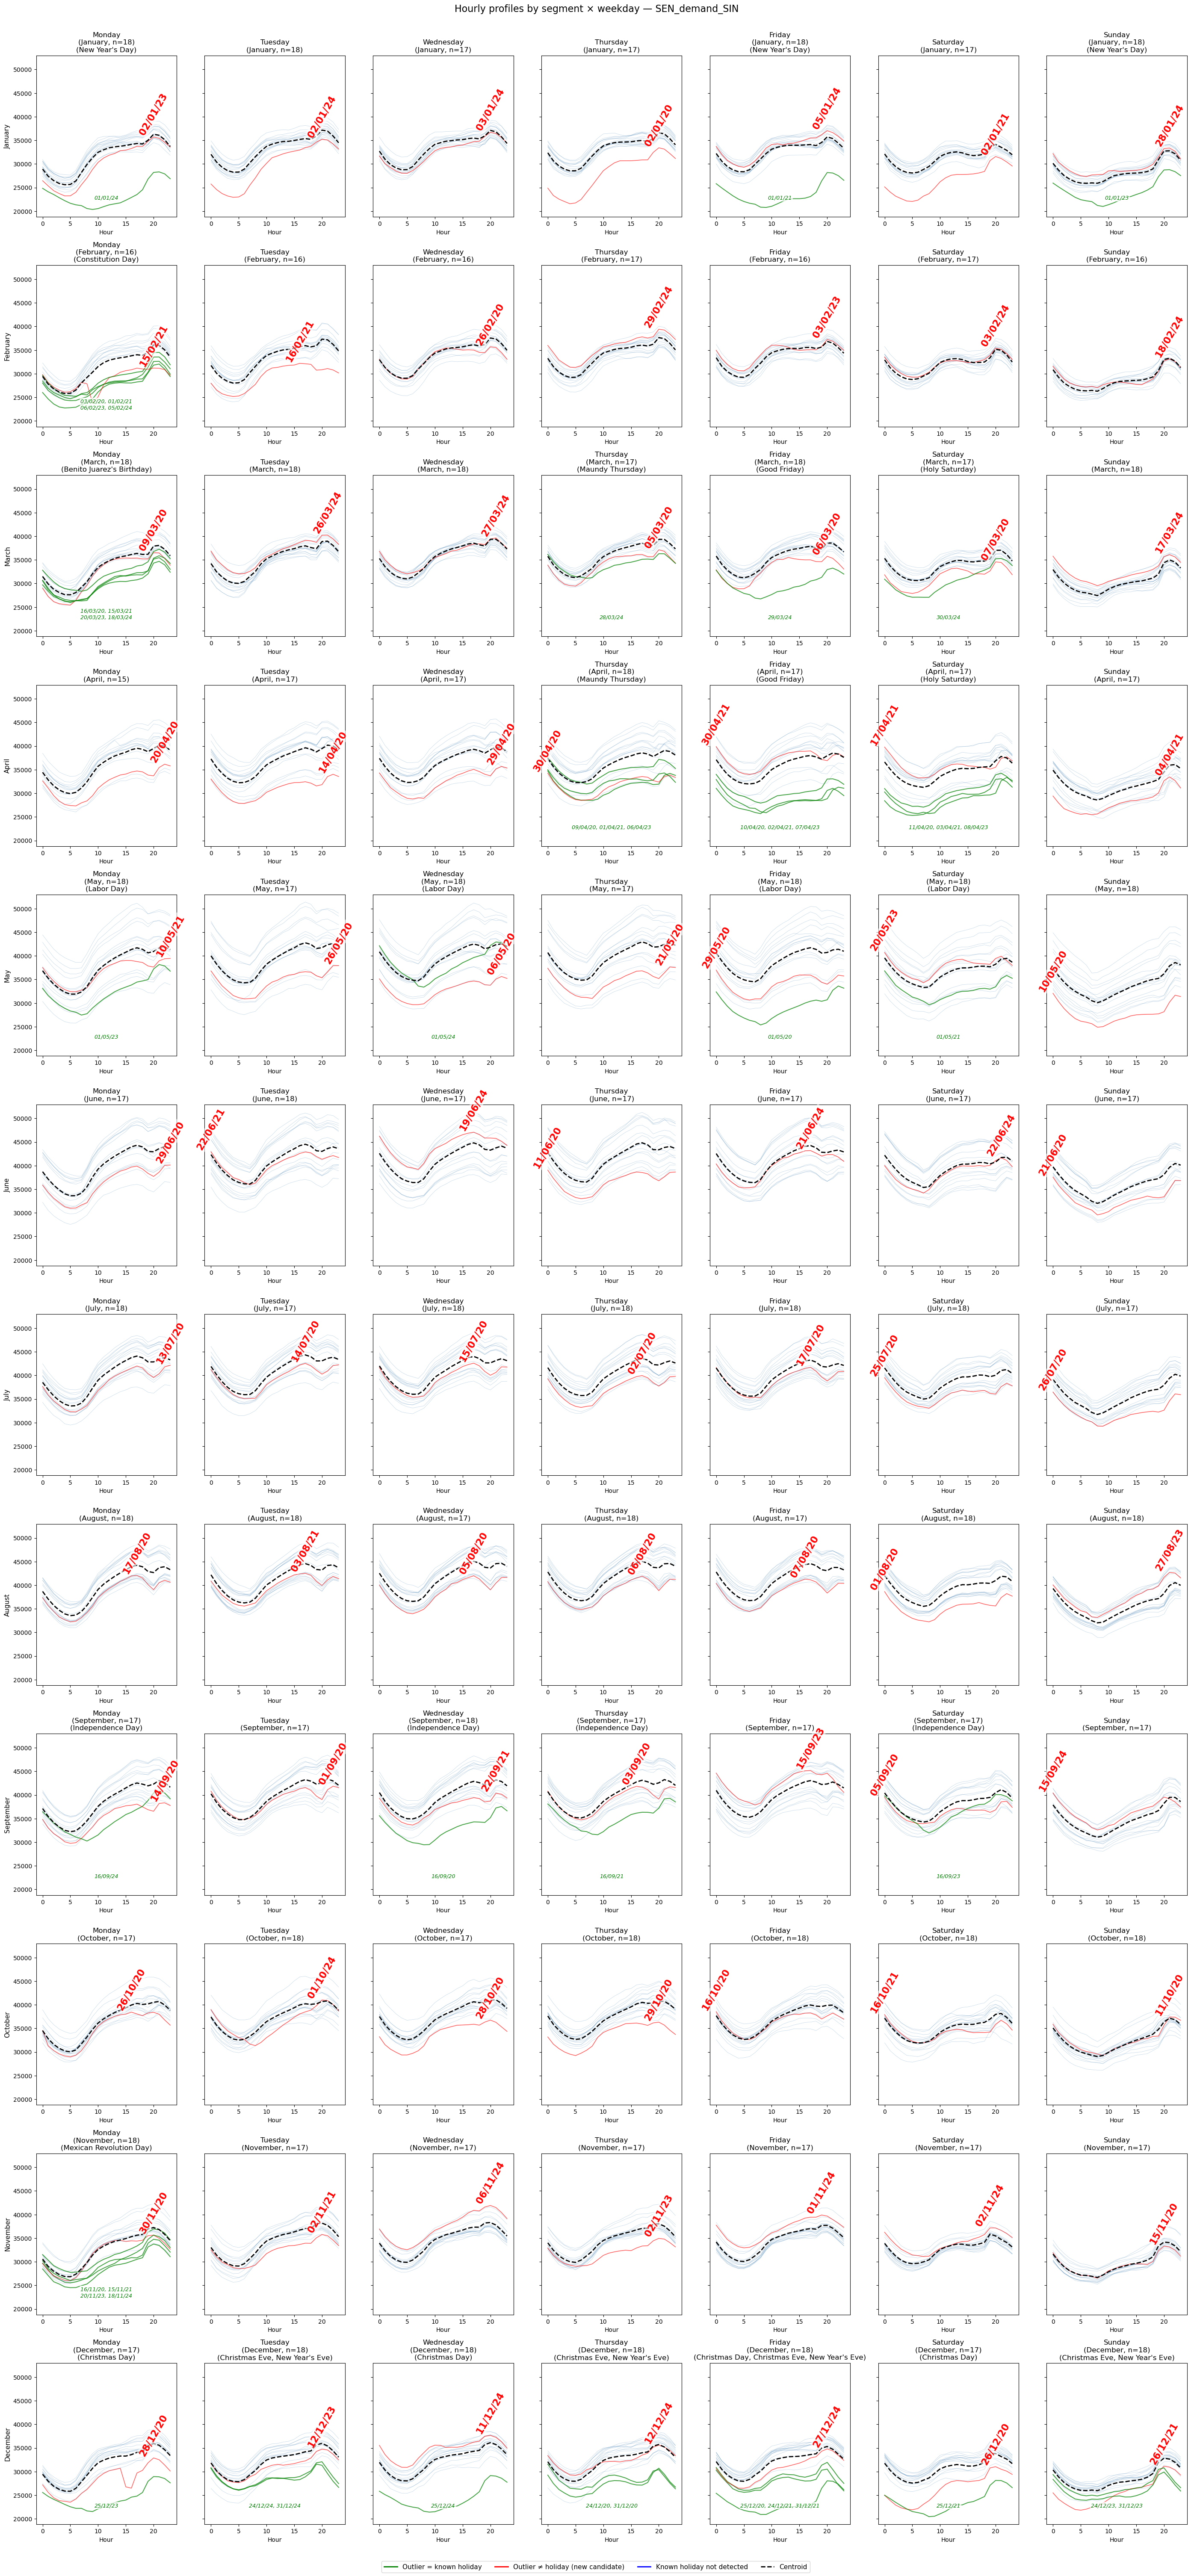

In [31]:
plot_profiles_by_segment_dow(
    df_wide, HOUR_COLS, SEGMENT_LABELS, WEEKDAY_NAMES,
    match_dates_set, unknown_dates_set, missed_dates_set, UNIQUE_ID,
    df_holidays=df_holidays_display,
)

Detected profiles use the same colors as the plotting helpers:

| Color | Meaning |
|---|---|
| Green | Detected outlier that matches a catalog holiday |
| Red | Detected outlier without a catalog match |
| Blue | Catalog holiday that was not flagged as an outlier |
| Black dashed line | Group centroid |
| Faint gray | Regular days |

## 8b. Hourly profiles by holiday

Each subplot overlays all available yearly profiles for one holiday present in the data.

| Color | Meaning |
|---|---|
| Green | Year detected as an outlier |
| Blue | Year present but not detected as an outlier |
| Black dashed line | Average holiday profile across years |

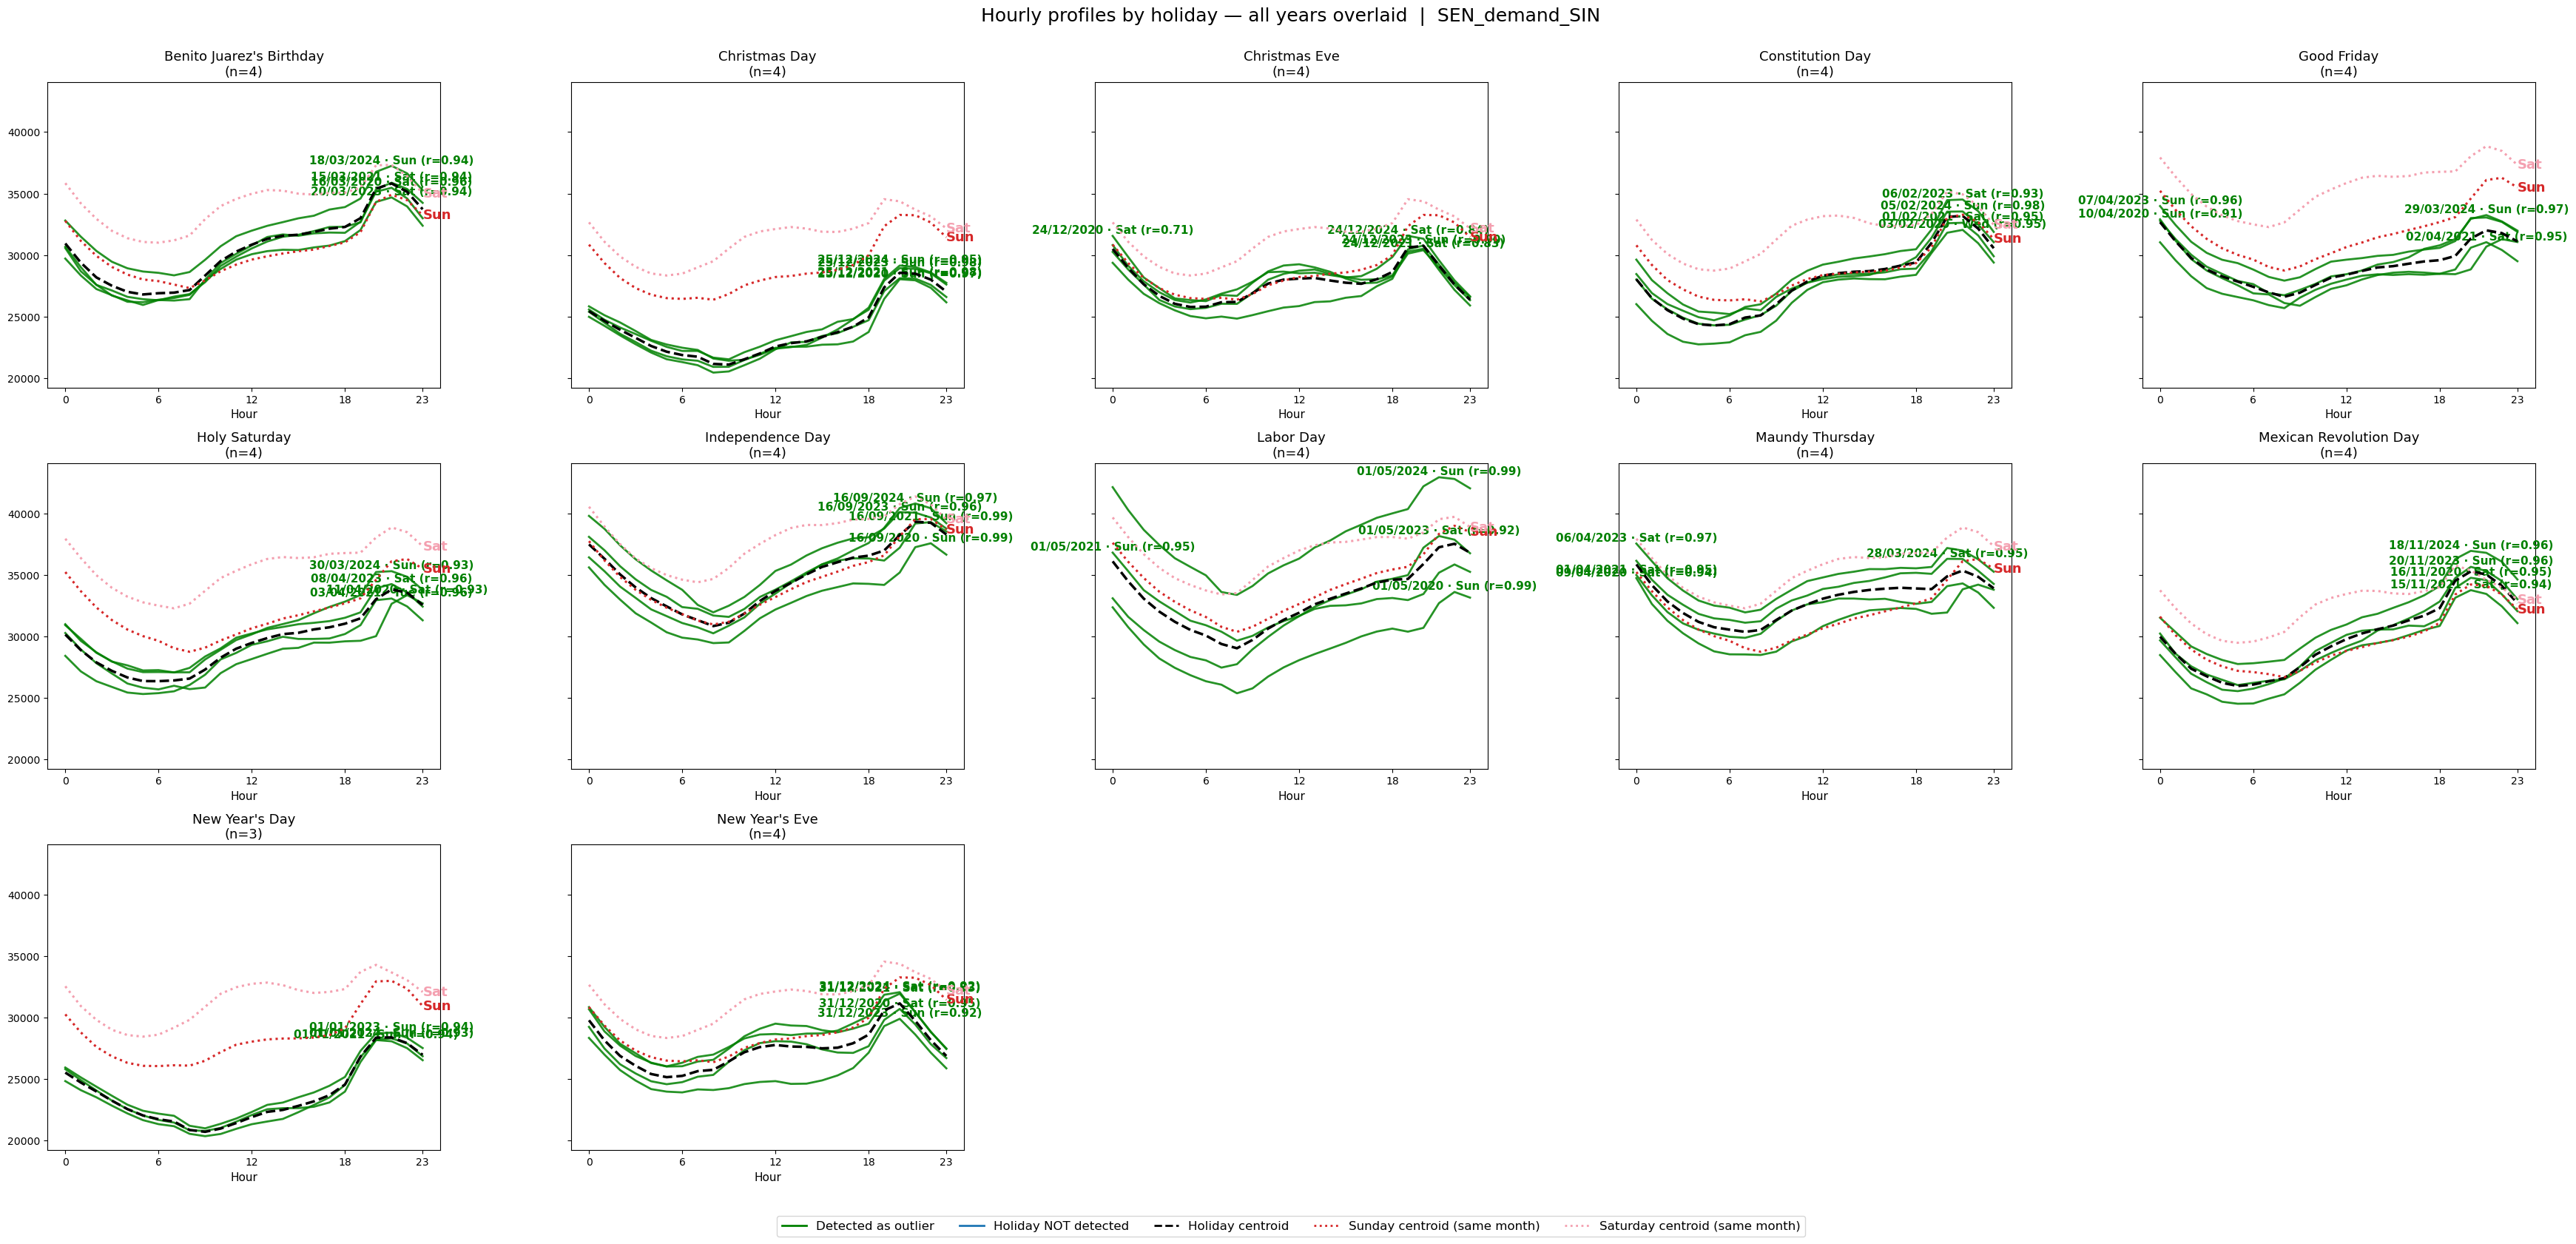

In [32]:
holiday_groups = build_holiday_groups(df_holidays_display, df_wide.index)

plot_profiles_by_holiday(
    df_wide, holiday_groups, df_holidays_display, HOUR_COLS,
    match_dates_set, outlier_dates_set, UNIQUE_ID,
)

## 8c. Cluster atypical profiles

This view clusters the detected atypical profiles and compares each cluster centroid against weekday reference profiles.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Similarity between each cluster centroid and the weekday reference profiles


,n days,r vs Mon,r vs Tue,r vs Wed,r vs Thu,r vs Fri,r vs Sat,r vs Sun,top holidays
Cluster,,,,,,,,,
0,22,0.590,0.677,0.686,0.692,0.667,0.854,0.996,"Good Friday, Independence Day, Christmas Day"
1,25,0.896,0.934,0.936,0.938,0.924,0.966,0.875,"Constitution Day, Benito Juarez's Birthday, Mexican Revolution Day"



Days per cluster


cluster,date,dow,type,holiday_name
0,2020-04-09,Thu,Confirmed holiday,Maundy Thursday
0,2020-04-10,Fri,Confirmed holiday,Good Friday
0,2020-04-11,Sat,Confirmed holiday,Holy Saturday
0,2020-05-01,Fri,Confirmed holiday,Labor Day
0,2020-09-16,Wed,Confirmed holiday,Independence Day
0,2020-12-25,Fri,Confirmed holiday,Christmas Day
0,2021-01-01,Fri,Confirmed holiday,New Year's Day
0,2021-04-02,Fri,Confirmed holiday,Good Friday
0,2021-05-01,Sat,Confirmed holiday,Labor Day
0,2021-09-16,Thu,Confirmed holiday,Independence Day


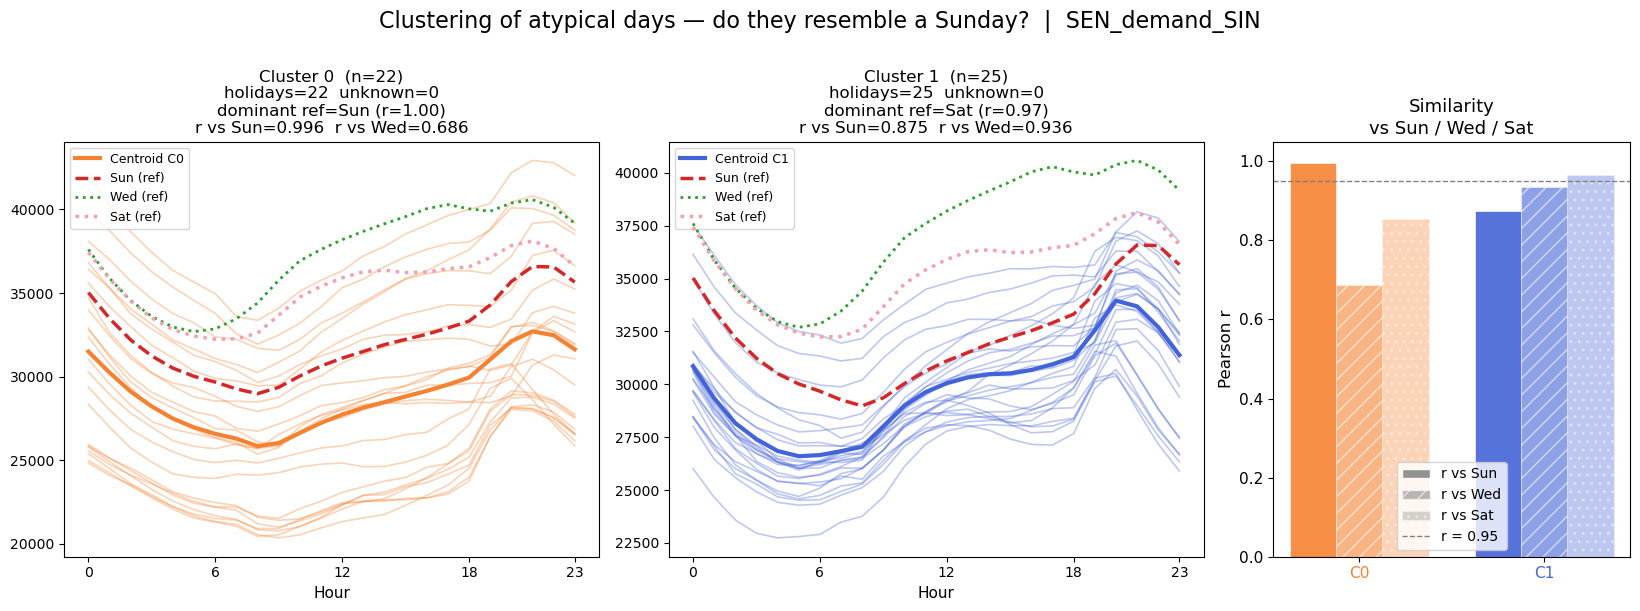

In [33]:
N_CLUSTERS = 2
CLUSTER_COLORS = [
    '#f58231',  '#4363d8', '#3cb44b', '#e6194b',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45',
]

cluster_results = run_cluster_atypical_analysis(
    df_wide,
    match_dates_set,
    set(),
    outlier_dates_set,
    N_CLUSTERS,
    HOUR_COLS,
    df_holidays_display,
    CLUSTER_COLORS,
    UNIQUE_ID,
)
df_atyp = cluster_results['df_atyp']
df_sim = cluster_results['df_sim']


## 8c-bis. Cluster: 38-h event profile (eve last 14 h + holiday 24 h)

For every confirmed holiday `D`, a single **38-hour feature vector** is built:

| Segment | Hours | Source |
|---------|-------|--------|
| Pre-holiday eve | last `PREVIOUSLY_W_HOURS = 14` h of day `D−1` (h10…h23) | `df_wide[D−1]` |
| Holiday | full 24 h of day `D` (h0…h23) | `df_wide[D]` |

KMeans is then applied to these 38-column profiles.  
Events where the eve day is missing from the data are skipped.


Events with complete 38-h profile: 46

Days per cluster


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


type,date,dow,holiday_name
C,2020-09-16,Wed,Independence Day
C,2021-04-01,Thu,Maundy Thursday
C,2021-05-01,Sat,Labor Day
C,2021-09-16,Thu,Independence Day
C,2023-04-06,Thu,Maundy Thursday
C,2023-09-16,Sat,Independence Day
C,2024-03-28,Thu,Maundy Thursday
C,2024-05-01,Wed,Labor Day
C,2024-09-16,Mon,Independence Day
D,2020-02-03,Mon,Constitution Day


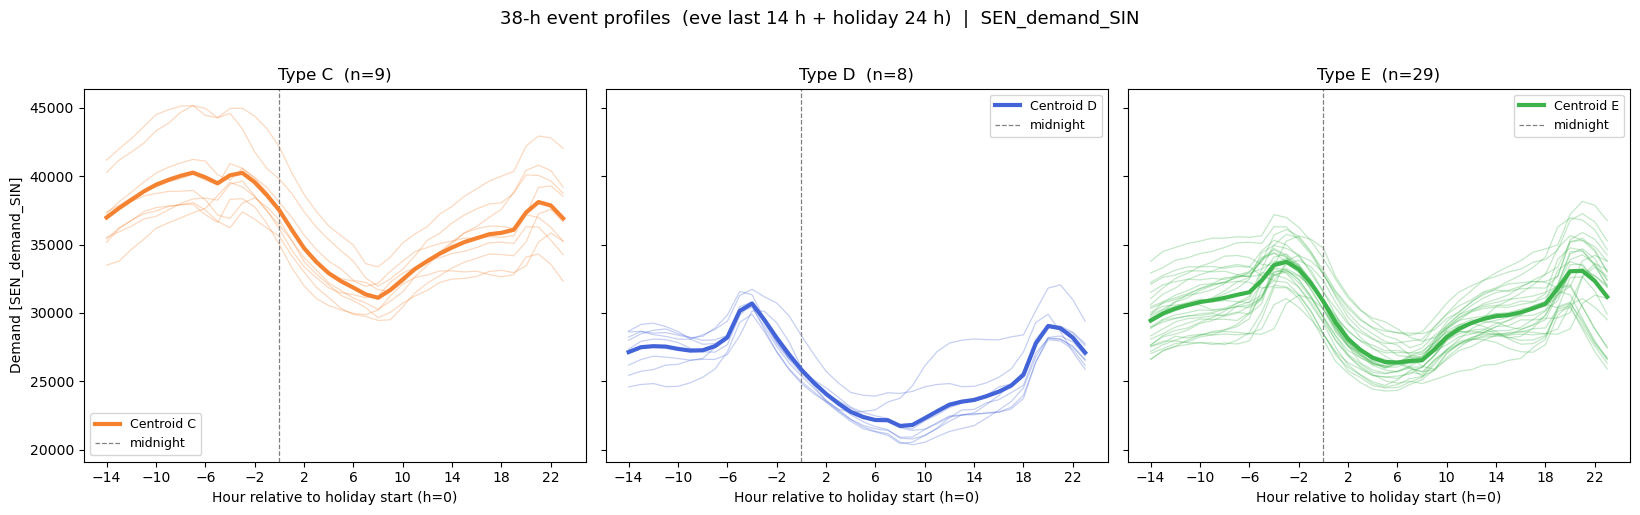

Holiday × Cluster  (38-h profiles)
Rows = holiday name   |   Columns = cluster type (count of events)



cluster_type,C,D,E
holiday_name,,,
Benito Juarez's Birthday,—,—,4
Christmas Day,—,4,—
Christmas Eve,—,—,4
Constitution Day,—,1,3
Good Friday,—,—,4
Holy Saturday,—,—,4
Independence Day,4,—,—
Labor Day,2,—,2
Maundy Thursday,3,—,1


In [34]:
cluster_38h_results = run_cluster_38h_analysis(
    df_wide=df_wide,
    match_dates_set=match_dates_set,
    df_holidays_display=df_holidays_display,
    hour_cols=HOUR_COLS,
    cluster_colors=CLUSTER_COLORS,
    unique_id=UNIQUE_ID,
    n_clusters=N_CLUSTERS_PHOL,
    previously_w_hours=PREVIOUSLY_W_HOURS,
)
df_phol      = cluster_38h_results['df_phol']
df_days_phol = cluster_38h_results['df_days_phol']

## 8d. Cluster DOW similarity

For each cluster, ranks all **7 day-of-week** reference profiles (Mon–Sun) by mean Pearson correlation, then tests statistically whether the top-ranked DOW is significantly better than the runner-up.

This avoids the ad-hoc Sat/Sun assumption: a cluster that resembles Wednesday and Sunday equally will show up as "not distinguishable", while a cluster that truly behaves like Saturday will have a clear green winner column.

| Output | Meaning |
|---|---|
| **Table 1 — mean corr** | Mean Pearson r of each cluster against each DOW centroid (same month). Green = highest, pink = lowest per row. |
| **Table 2 — votes** | Number of days in the cluster where each DOW was the best individual match. |
| **Table 3 — per-day** | Every atypical day with its 7 correlation values; green = best DOW for that day. |
| `best_dow` | DOW with highest mean r (winner). |
| `runner_up_dow` | Second-best DOW. |
| `gap_corr` | Mean r of winner minus mean r of runner-up. |
| `wilcoxon_pvalue` | One-sided Wilcoxon on (r_winner − r_runner_up) per day: p < alpha → winner is unambiguously better. |
| `cluster_type` | Winner DOW label if significant, `'unclear'` otherwise. |


In [35]:
AB_ALPHA = 0.10

cluster_ab_results = run_cluster_ab_validation(
    df_wide=df_wide,
    df_atyp=df_atyp,
    outlier_dates_set=outlier_dates_set,
    hour_cols=HOUR_COLS,
    cluster_colors=CLUSTER_COLORS,
    alpha=AB_ALPHA,
    df_holidays=df_holidays_display,
)

# cluster_type: winner DOW label (e.g. 'Sat', 'Sun') if statistically clear, else 'unclear'
cluster_type_map = dict(
    zip(
        cluster_ab_results['summary_df']['cluster'],
        cluster_ab_results['summary_df']['cluster_type'],
    )
)
print('cluster_type_map =', cluster_type_map)


Cluster DOW similarity  (alpha = 0.1)
Mean Pearson r of each cluster against the 7 DOW reference profiles.



cluster,n_days,Mon,Tue,Wed,Thu,Fri,Sat,Sun,best_dow,runner_up_dow,gap_corr,wilcoxon_pvalue,decision
0,22,0.561,0.649,0.654,0.656,0.633,0.808,0.953,Sun,Sat,0.145,0.0000,"Sun-like (Δr=0.145, p=0.0000)"
1,25,0.815,0.854,0.860,0.866,0.855,0.917,0.852,Sat,Thu,0.052,0.0000,"Sat-like (Δr=0.052, p=0.0000)"



Vote counts — best-matching DOW per day


cluster,n_days,Mon,Tue,Wed,Thu,Fri,Sat,Sun,best_dow
0,22,0,0,0,0,0,3,19,Sun
1,25,0,1,1,0,0,18,5,Sat



Per-day detail


cluster,date,profile_type,best_dow,corr_Mon,corr_Tue,corr_Wed,corr_Thu,corr_Fri,corr_Sat,corr_Sun
0,2020-04-09,Maundy Thursday,Sat,0.673,0.796,0.809,0.813,0.798,0.938,0.932
0,2020-04-10,Good Friday,Sun,0.284,0.451,0.469,0.474,0.451,0.729,0.907
0,2020-04-11,Holy Saturday,Sat,0.780,0.857,0.857,0.856,0.836,0.935,0.931
0,2020-05-01,Labor Day,Sun,0.691,0.773,0.794,0.787,0.789,0.942,0.991
0,2020-09-16,Independence Day,Sun,0.724,0.806,0.821,0.810,0.799,0.935,0.986
0,2020-12-25,Christmas Day,Sun,0.507,0.567,0.563,0.575,0.525,0.721,0.967
0,2021-01-01,New Year's Day,Sun,0.373,0.462,0.427,0.430,0.396,0.569,0.936
0,2021-04-02,Good Friday,Sat,0.638,0.758,0.773,0.772,0.757,0.950,0.949
0,2021-05-01,Labor Day,Sun,0.444,0.561,0.600,0.584,0.611,0.861,0.949
0,2021-09-16,Independence Day,Sun,0.626,0.725,0.744,0.732,0.721,0.894,0.987


cluster_type_map = {0: 'Sun', 1: 'Sat'}


In [36]:
df_cluster_holiday_crosstab = display_cluster_holiday_crosstab(
    df_atyp=df_atyp,
    df_holidays=df_holidays_display,
    cluster_colors=CLUSTER_COLORS,
)


Holiday × Cluster distribution
Rows = holiday name   |   Columns = cluster (count of days)



cluster,Cluster 0,Cluster 1
holiday_name,,
Benito Juarez's Birthday,—,4
Christmas Day,4,—
Christmas Eve,1,3
Constitution Day,—,4
Good Friday,4,—
Holy Saturday,1,3
Independence Day,4,—
Labor Day,3,1
Maundy Thursday,1,3


## 9. Holiday Selector Feature Schema

The selector table `df_holiday_selector_features` combines calendar rules and profile-based labels so analog candidates can be filtered or ranked by context before distance ranking.

| Field | Meaning | Typical values / source |
|---|---|---|
| `holiday_name` | Name assigned to the row itself. For `H1`/`H2`/`H3` rows this is the holiday on that date. For `H4` rows this is the synthetic recovery label. | `Labor Day`, `Good Friday`, `Post-holiday recovery` |
| `anchor_holiday_name` | Anchor holiday used to identify the event family behind the row. For `H1`/`H2`/`H3` it matches `holiday_name`. For `H4` it is the last holiday in the immediately preceding run. | `Christmas Day`, `New Year's Day` |
| `date` | Calendar date represented by the row. | `2020-05-01` |
| `holiday_day_type` | H-day taxonomy label. `H1` = eve day, `H2` = core or standalone holiday, `H3` = consecutive post-holiday day, `H4` = first recovery day after a run of length >= 2. | `H1`, `H2`, `H3`, `H4` |
| `weekday_name` | Literal weekday of `date`, independent of demand similarity. | `Monday`, `Saturday`, `Sunday` |
| `day_class_code` | Compact labor-calendar code used by the selector. `1` = weekday, `2` = Saturday, `3` = Sunday. | `1`, `2`, `3` |
| `day_class_name` | Expanded text version of `day_class_code`. | `Weekday`, `Saturday`, `Sunday` |
| `season` | Meteorological season derived from the month. | `Winter`, `Spring`, `Summer`, `Autumn` |
| `date_rule` | Calendar rule behind the date. `fixed_date` = fixed official date, `observed_monday_rule` = Monday-observed civic holiday after the 2006 labor reform, `movable_date` = Easter-based movable holiday, `derived_recovery_day` = synthetic `H4` row. | `fixed_date`, `observed_monday_rule`, `movable_date`, `derived_recovery_day` |
| `is_fixed_date` | Boolean helper flag for fixed-date observances. This is also `True` for pre-2006 years of Monday-observed civic holidays, when they still fell on their original fixed date. | `True`, `False` |
| `is_observed_monday_rule` | Boolean helper flag for civic holidays shifted to Monday by the 2006 labor reform. | `True`, `False` |
| `best_matching_weekday` | Best weekday match at the individual-day level, taken from section 8d (`best_dow`) and expanded to full weekday names. This is the closest weekday profile for that specific date. | `Saturday`, `Sunday`, `Wednesday` |
| `daily_profile_cluster` | DOW-agnostic letter for the daily-profile cluster from section 8c. It is derived from `daily_profile_cluster_id` in ascending numeric order, so the current notebook typically shows `A`, `B`, etc. | `A`, `B`, `C` |
| `daily_profile_cluster_id` | Raw numeric KMeans cluster id from section 8c (atypical daily profiles). | `0`, `1`, `2` |
| `daily_profile_archetype` | Cluster-level weekday archetype inferred from section 8d (`cluster_type`). This is the human-readable interpretation of the cluster, such as `Saturday-like`, `Sunday-like`, or `unclear`. | `Saturday-like`, `Sunday-like`, `unclear` |
| `event_profile_cluster` | DOW-agnostic letter for the 38-h event-profile cluster from section 8c-bis. The current notebook typically shows `C`, `D`, `E`, etc. | `C`, `D`, `E` |
| `event_profile_cluster_id` | Raw numeric KMeans cluster id from section 8c-bis (38-h eve + holiday profile). | `0`, `1`, `2` |

Notes:

- `best_matching_weekday` is a per-date label, while `daily_profile_archetype` is a cluster-level label.
- `daily_profile_cluster` / `daily_profile_cluster_id` come from the 24-h atypical-day analysis in section 8c.
- `event_profile_cluster` / `event_profile_cluster_id` come from the 38-h eve+holiday analysis in section 8c-bis.
- `H4` rows are derived automatically and may not have event-profile labels because the 38-h clustering is defined only for confirmed holiday dates.
- Missing values in cluster-related columns are acceptable when a row was not part of the corresponding upstream analysis.
- For future candidates, profile-based labels are inferred first within the same `anchor_holiday_name` + `holiday_day_type` family and, if that subtype has no observed evidence, they fall back to the broader `anchor_holiday_name` history.

In [37]:
# 9. Holiday selector feature table (historical window only)
from analog_holidays.shared.identify_holidays import build_holiday_selector_features

df_holiday_selector_features_history = build_holiday_selector_features(
    df_wide=df_wide,
    df_holidays=df_holidays_display,
    cluster_ab_results=cluster_ab_results,
    df_phol=df_phol,
    holidays_path=HOLIDAYS_PATH,
)

print(f'Historical selector rows: {len(df_holiday_selector_features_history)}')
display(df_holiday_selector_features_history)

Historical selector rows: 57


,holiday_name,anchor_holiday_name,date,holiday_day_type,weekday_name,day_class_code,day_class_name,season,date_rule,is_fixed_date,is_observed_monday_rule,best_matching_weekday,daily_profile_cluster,daily_profile_cluster_id,daily_profile_archetype,event_profile_cluster,event_profile_cluster_id
0,Constitution Day,Constitution Day,2020-02-03,H2,Monday,1,Weekday,Winter,observed_monday_rule,False,True,Wednesday,B,1,Saturday-like,D,1
1,Benito Juarez's Birthday,Benito Juarez's Birthday,2020-03-16,H2,Monday,1,Weekday,Spring,observed_monday_rule,False,True,Saturday,B,1,Saturday-like,E,2
2,Maundy Thursday,Maundy Thursday,2020-04-09,H1,Thursday,1,Weekday,Spring,movable_date,False,False,Saturday,A,0,Sunday-like,E,2
3,Good Friday,Good Friday,2020-04-10,H2,Friday,1,Weekday,Spring,movable_date,False,False,Sunday,A,0,Sunday-like,E,2
4,Holy Saturday,Holy Saturday,2020-04-11,H3,Saturday,2,Saturday,Spring,movable_date,False,False,Saturday,A,0,Sunday-like,E,2
5,Post-holiday recovery,Holy Saturday,2020-04-12,H4,Sunday,3,Sunday,Spring,derived_recovery_day,False,False,NaN,NaN,<NA>,NaN,NaN,<NA>
6,Labor Day,Labor Day,2020-05-01,H2,Friday,1,Weekday,Spring,fixed_date,True,False,Sunday,A,0,Sunday-like,E,2
7,Independence Day,Independence Day,2020-09-16,H2,Wednesday,1,Weekday,Autumn,fixed_date,True,False,Sunday,A,0,Sunday-like,C,0
8,Mexican Revolution Day,Mexican Revolution Day,2020-11-16,H2,Monday,1,Weekday,Autumn,observed_monday_rule,False,True,Saturday,B,1,Saturday-like,E,2
9,Christmas Eve,Christmas Eve,2020-12-24,H1,Thursday,1,Weekday,Winter,fixed_date,True,False,Saturday,B,1,Saturday-like,E,2


In [38]:
# 10. Ex-ante profile priors for new candidates
# Priors are estimated only on the historical selector rows above.
from analog_holidays.shared.identify_holidays import (
    build_future_holiday_selector_features,
    build_holiday_selector_priors,
)

selector_features_path = Path('holidays') / 'holiday_selector_features.csv'
selector_priors_path = Path('holidays') / 'holiday_selector_priors.csv'

df_holiday_selector_priors = build_holiday_selector_priors(
    df_holiday_selector_features_history,
    group_cols=('anchor_holiday_name', 'holiday_day_type'),
)

source_ds = pd.read_csv(DEMAND_PATH, usecols=['ds'], parse_dates=['ds'])['ds']
source_available_dates = set(source_ds.dt.normalize())
selector_future_start = (
    pd.Timestamp(DATE_END).normalize()
    if DATE_END is not None
    else pd.to_datetime(df_holiday_selector_features_history['date']).max().normalize() + pd.Timedelta(days=1)
)
selector_future_end = (
    pd.Timestamp(SELECTOR_FUTURE_END).normalize()
    if SELECTOR_FUTURE_END is not None
    else source_ds.max().normalize()
)
df_holidays_selector_source = load_holidays_catalog(
    HOLIDAYS_PATH,
    year_min,
    int(selector_future_end.year),
)

df_holiday_selector_features_future = build_future_holiday_selector_features(
    df_holidays=df_holidays_selector_source,
    df_priors=df_holiday_selector_priors,
    available_dates=source_available_dates,
    holidays_path=HOLIDAYS_PATH,
    group_cols=('anchor_holiday_name', 'holiday_day_type'),
    start_date=selector_future_start,
    end_date=selector_future_end,
)

df_holiday_selector_features = (
    pd.concat(
        [df_holiday_selector_features_history, df_holiday_selector_features_future],
        ignore_index=True,
    )
    .sort_values(['date', 'holiday_name'])
    .reset_index(drop=True)
)

df_holiday_selector_features_export = df_holiday_selector_features.copy()
df_holiday_selector_features_export['date'] = (
    pd.to_datetime(df_holiday_selector_features_export['date'])
    .dt.strftime('%Y-%m-%d')
)
df_holiday_selector_features_export.to_csv(selector_features_path, index=False)

df_holiday_selector_priors_export = df_holiday_selector_priors.copy()
df_holiday_selector_priors_export.to_csv(selector_priors_path, index=False)

print(f'Historical selector rows: {len(df_holiday_selector_features_history)}')
print(f'Future ex-ante rows: {len(df_holiday_selector_features_future)}')
print(f'Total selector rows exported: {len(df_holiday_selector_features_export)}')
print(f'Selector CSV saved to: {selector_features_path.resolve()}')
print(f'Priors CSV saved to: {selector_priors_path.resolve()}')
display(df_holiday_selector_priors)
display(df_holiday_selector_features_future)

Historical selector rows: 57
Future ex-ante rows: 30
Total selector rows exported: 87
Selector CSV saved to: C:\GIT\analog_holidays\holidays\holiday_selector_features.csv
Priors CSV saved to: C:\GIT\analog_holidays\holidays\holiday_selector_priors.csv


,anchor_holiday_name,holiday_day_type,history_rows,history_years,inferred_best_matching_weekday,inferred_daily_profile_cluster,inferred_daily_profile_cluster_id,inferred_daily_profile_archetype,inferred_event_profile_cluster,inferred_event_profile_cluster_id
0,Benito Juarez's Birthday,H2,4,4,Saturday,B,1,Saturday-like,E,2
1,Christmas Day,H2,4,4,Sunday,A,0,Sunday-like,D,1
2,Christmas Day,H4,4,4,Sunday,A,0,Sunday-like,D,1
3,Christmas Eve,H1,4,4,Saturday,B,1,Saturday-like,E,2
4,Constitution Day,H2,4,4,Saturday,B,1,Saturday-like,E,2
5,Good Friday,H2,4,4,Sunday,A,0,Sunday-like,E,2
6,Holy Saturday,H3,4,4,Saturday,B,1,Saturday-like,E,2
7,Holy Saturday,H4,4,4,Saturday,B,1,Saturday-like,E,2
8,Independence Day,H2,4,4,Sunday,A,0,Sunday-like,C,0
9,Labor Day,H2,4,4,Sunday,A,0,Sunday-like,C,0


,holiday_name,anchor_holiday_name,date,holiday_day_type,weekday_name,day_class_code,day_class_name,season,date_rule,is_fixed_date,is_observed_monday_rule,best_matching_weekday,daily_profile_cluster,daily_profile_cluster_id,daily_profile_archetype,event_profile_cluster,event_profile_cluster_id
0,New Year's Day,New Year's Day,2025-01-01,H3,Wednesday,1,Weekday,Winter,fixed_date,True,False,Sunday,A,0,Sunday-like,D,1
1,Post-holiday recovery,New Year's Day,2025-01-02,H4,Thursday,1,Weekday,Winter,derived_recovery_day,False,False,Sunday,A,0,Sunday-like,D,1
2,Constitution Day,Constitution Day,2025-02-03,H2,Monday,1,Weekday,Winter,observed_monday_rule,False,True,Saturday,B,1,Saturday-like,E,2
3,Benito Juarez's Birthday,Benito Juarez's Birthday,2025-03-17,H2,Monday,1,Weekday,Spring,observed_monday_rule,False,True,Saturday,B,1,Saturday-like,E,2
4,Maundy Thursday,Maundy Thursday,2025-04-17,H1,Thursday,1,Weekday,Spring,movable_date,False,False,Saturday,B,1,Saturday-like,C,0
5,Good Friday,Good Friday,2025-04-18,H2,Friday,1,Weekday,Spring,movable_date,False,False,Sunday,A,0,Sunday-like,E,2
6,Holy Saturday,Holy Saturday,2025-04-19,H3,Saturday,2,Saturday,Spring,movable_date,False,False,Saturday,B,1,Saturday-like,E,2
7,Post-holiday recovery,Holy Saturday,2025-04-20,H4,Sunday,3,Sunday,Spring,derived_recovery_day,False,False,Saturday,B,1,Saturday-like,E,2
8,Labor Day,Labor Day,2025-05-01,H2,Thursday,1,Weekday,Spring,fixed_date,True,False,Sunday,A,0,Sunday-like,C,0
9,Independence Day,Independence Day,2025-09-16,H2,Tuesday,1,Weekday,Autumn,fixed_date,True,False,Sunday,A,0,Sunday-like,C,0


## 11. Analog-Space Clusters (`F`, `G`, `H`)

The internal grouping rule may evolve over time (`event_profile_cluster`, `daily_profile_cluster`, direct priors, or another criterion), but the output analog-space labels remain stable and human-facing: `F`, `G`, `H`, ...

Historical rows determine the analog-space mapping. Future holiday rows in the 2025/2026 test horizon receive their profile labels ex-ante from `holiday_selector_priors.csv`, so the exported selector can be filled without using future observations.

The selector export `holidays/holiday_selector_features.csv` is the single source of truth for daily `analog_cluster` labels. No hourly `*_cluster` columns are added to the demand source anymore.

In [39]:
from analog_holidays.shared.identify_holidays import assign_holiday_selector_analog_clusters

analog_cluster_results = assign_holiday_selector_analog_clusters(
    df_selector=df_holiday_selector_features,
    df_priors=df_holiday_selector_priors,
    criterion='event_profile_cluster',
    group_cols=('anchor_holiday_name', 'holiday_day_type'),
    cluster_labels=('F', 'G', 'H'),
)
df_holiday_selector_analog_clusters = analog_cluster_results['df_selector_clusters']
df_analog_cluster_catalog = analog_cluster_results['analog_cluster_catalog']

df_holiday_selector_features = (
    df_holiday_selector_analog_clusters
    .drop(
        columns=[
            'analog_criterion',
            'analog_criterion_value',
            'inferred_event_profile_cluster',
        ],
        errors='ignore',
    )
    .sort_values(['date', 'holiday_name'])
    .reset_index(drop=True)
)
selector_features_path = Path('holidays') / 'holiday_selector_features.csv'
df_holiday_selector_features_export = df_holiday_selector_features.copy()
df_holiday_selector_features_export['date'] = (
    pd.to_datetime(df_holiday_selector_features_export['date'])
    .dt.strftime('%Y-%m-%d')
)
df_holiday_selector_features_export.to_csv(selector_features_path, index=False)

print(f'Catalog rows: {len(df_analog_cluster_catalog)}')
print(f'Selector CSV saved to: {selector_features_path.resolve()}')
display(df_analog_cluster_catalog)
display(
    df_holiday_selector_features[
        [
            'holiday_name',
            'anchor_holiday_name',
            'date',
            'holiday_day_type',
            'event_profile_cluster',
            'analog_cluster',
        ]
    ].sort_values('date').reset_index(drop=True)
)

Catalog rows: 3
Selector CSV saved to: C:\GIT\analog_holidays\holidays\holiday_selector_features.csv


,analog_cluster,analog_criterion,analog_criterion_value,n_rows,n_anchor_holidays
0,F,event_profile_cluster,C,15,3
1,G,event_profile_cluster,D,24,4
2,H,event_profile_cluster,E,48,9


,holiday_name,anchor_holiday_name,date,holiday_day_type,event_profile_cluster,analog_cluster
0,Constitution Day,Constitution Day,2020-02-03,H2,D,G
1,Benito Juarez's Birthday,Benito Juarez's Birthday,2020-03-16,H2,E,H
2,Maundy Thursday,Maundy Thursday,2020-04-09,H1,E,H
3,Good Friday,Good Friday,2020-04-10,H2,E,H
4,Holy Saturday,Holy Saturday,2020-04-11,H3,E,H
...,...,...,...,...,...,...
82,Mexican Revolution Day,Mexican Revolution Day,2026-11-16,H2,E,H
83,Christmas Eve,Christmas Eve,2026-12-24,H1,E,H
84,Christmas Day,Christmas Day,2026-12-25,H2,D,G
85,Post-holiday recovery,Christmas Day,2026-12-26,H4,D,G


## 12. Final summary

In [40]:
print_summary(
    UNIQUE_ID, df_wide, n_total, n_match, n_unknown,
    df_missed, df_outliers_cmp, OUTLIER_PERCENTILE, WEEKDAY_NAMES,
)

Holiday identification summary
Series: SEN_demand_SIN
Range: 2020-01-02 to 2024-12-31
Days analyzed: 1459
Outlier threshold: percentile 95
Detected outliers: 131
Match the holiday catalog: 47
New candidates: 84
Known holidays not detected: 0

Outlier dates
  2020-01-02 (Thursday)
  2020-02-03 (Monday)
  2020-02-26 (Wednesday)
  2020-03-05 (Thursday)
  2020-03-06 (Friday)
  2020-03-07 (Saturday)
  2020-03-09 (Monday)
  2020-03-16 (Monday)
  2020-04-09 (Thursday)
  2020-04-10 (Friday)
  2020-04-11 (Saturday)
  2020-04-14 (Tuesday)
  2020-04-20 (Monday)
  2020-04-29 (Wednesday)
  2020-04-30 (Thursday)
  2020-05-01 (Friday)
  2020-05-06 (Wednesday)
  2020-05-10 (Sunday)
  2020-05-21 (Thursday)
  2020-05-26 (Tuesday)
  2020-05-29 (Friday)
  2020-06-11 (Thursday)
  2020-06-21 (Sunday)
  2020-06-29 (Monday)
  2020-07-02 (Thursday)
  2020-07-13 (Monday)
  2020-07-14 (Tuesday)
  2020-07-15 (Wednesday)
  2020-07-17 (Friday)
  2020-07-25 (Saturday)
  2020-07-26 (Sunday)
  2020-08-01 (Saturday)
  